In [1]:
import os
os.environ["HF_HOME"] = "/raid/s3/opengptx/behzad_shomali/custom_hf_cache/"

import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from collections import defaultdict
from trl import setup_chat_format

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
from pathlib import Path
import os

In [3]:
# ---- Settings ----
# base_model_name = "meta-llama/Llama-3.2-3B"
# finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-18_41_56/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-20_53_57/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_02-11_13_11/checkpoint-2000/lora_merged/"

# base_model_name = "Behzadshomali/Teuken3.7B"
finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/hf_converted/recuEmbed-math-group-rec_3_last3__6_7_8__-2025-10-17__13-07-48"

sample_text = "Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?"

# ---- Load models ----
# base_model = AutoModel.from_pretrained(base_model_name, output_hidden_states=True, trust_remote_code=True)
ft_model = AutoModel.from_pretrained(finetuned_model_name, output_hidden_states=True, trust_remote_code=True).to("cuda:0")
tokenizer = AutoTokenizer.from_pretrained(finetuned_model_name)

# if tokenizer.chat_template is None:
#     base_model, tokenizer = setup_chat_format(base_model, tokenizer)

# # Put models in eval mode
# base_model.eval()
ft_model.eval()


GPT2Model(
  (embed_tokens): Embedding(251008, 1024, padding_idx=0)
  (layers): ModuleList(
    (0-5): 6 x GPT2DecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (up_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (down_proj): Linear(in_features=2816, out_features=1024, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (6): GroupRecursiveGPT2DecoderLayer(
      (gpt2_blocks): ModuleList(
  

In [5]:
ft_model

GPT2Model(
  (embed_tokens): Embedding(251008, 1024, padding_idx=0)
  (layers): ModuleList(
    (0-5): 6 x GPT2DecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (up_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (down_proj): Linear(in_features=2816, out_features=1024, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (6): GroupRecursiveGPT2DecoderLayer(
      (gpt2_blocks): ModuleList(
  

In [9]:
# ---- Weight Differences ----
weight_diffs = []
layer_names = []

with torch.no_grad():
    for (n1, p1), (n2, p2) in zip(base_model.named_parameters(), ft_model.named_parameters()):
        if p1.shape == p2.shape:
            diff = (p1 - p2).abs().mean().item()
            weight_diffs.append(diff)
            layer_names.append(n1)
        else:
            print(f"Skipping {n1} due to shape mismatch: {p1.shape} vs {p2.shape}")

# ---- Activation Differences ----
inputs = tokenizer(sample_text, return_tensors="pt")

with torch.no_grad():
    base_out = base_model(**inputs)
    ft_out = ft_model(**inputs)

# Extract hidden states (list of [batch, seq_len, hidden_size])
base_hs = base_out.hidden_states
ft_hs = ft_out.hidden_states

act_diffs = []
layer_ids = list(range(len(base_hs)))

for h1, h2 in zip(base_hs, ft_hs):
    diff = (h1.mean(dim=(0,1)) - h2.mean(dim=(0,1))).abs().mean().item()
    act_diffs.append(diff)



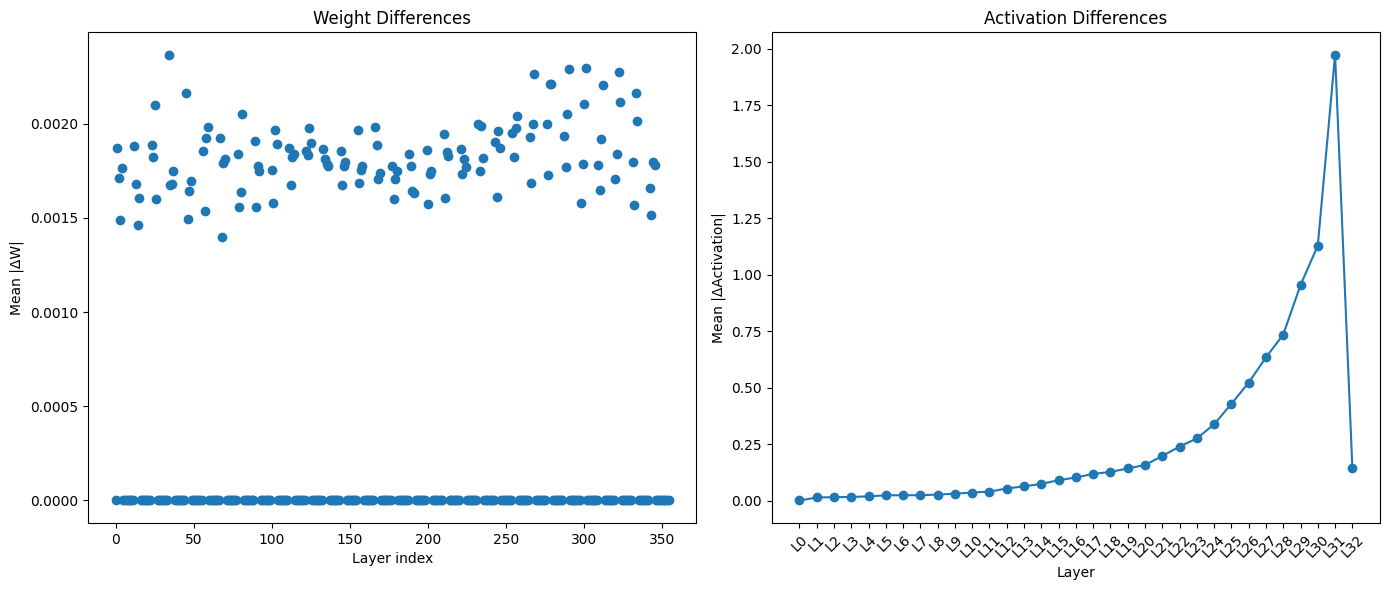

In [10]:
# ---- Plot ----
plt.figure(figsize=(14,6))

# Plot weight differences
plt.subplot(1,2,1)
plt.scatter(range(len(weight_diffs)), weight_diffs, marker='o')
plt.title("Weight Differences")
plt.xlabel("Layer index")
plt.ylabel("Mean |ΔW|")
plt.tight_layout()

# Plot activation differences
plt.subplot(1,2,2)
plt.plot(layer_ids, act_diffs, marker='o')
plt.xticks(range(len(layer_ids)), [f"L{i}" for i in layer_ids], rotation=45)
plt.title("Activation Differences")
plt.xlabel("Layer")
plt.ylabel("Mean |ΔActivation|")

plt.tight_layout()
plt.show()

In [11]:
for i in range(len(weight_diffs)):
    print(f"Layer {layer_names[i]} --> Weight Diff = {weight_diffs[i]:.6f}")

Layer embed_tokens.weight --> Weight Diff = 0.000004
Layer layers.0.self_attn.q_proj.weight --> Weight Diff = 0.001869
Layer layers.0.self_attn.k_proj.weight --> Weight Diff = 0.001713
Layer layers.0.self_attn.v_proj.weight --> Weight Diff = 0.001491
Layer layers.0.self_attn.o_proj.weight --> Weight Diff = 0.001768
Layer layers.0.mlp.gate_proj.weight --> Weight Diff = 0.000000
Layer layers.0.mlp.up_proj.weight --> Weight Diff = 0.000000
Layer layers.0.mlp.down_proj.weight --> Weight Diff = 0.000000
Layer layers.0.input_layernorm.weight --> Weight Diff = 0.000000
Layer layers.0.input_layernorm.bias --> Weight Diff = 0.000000
Layer layers.0.post_attention_layernorm.weight --> Weight Diff = 0.000000
Layer layers.0.post_attention_layernorm.bias --> Weight Diff = 0.000000
Layer layers.1.self_attn.q_proj.weight --> Weight Diff = 0.001880
Layer layers.1.self_attn.k_proj.weight --> Weight Diff = 0.001682
Layer layers.1.self_attn.v_proj.weight --> Weight Diff = 0.001460
Layer layers.1.self_attn

In [1]:
from pathlib import Path

In [8]:
file_dir = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/"
file_dir = Path(file_dir)
json_files = [f for f in file_dir.glob("*.json") if f.is_file() and "results" in f.name]
json_files

[PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T16-24-08.464414.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T17-06-05.599449.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T17-23-45.980589.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T15-53-26.500130.json')]

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from transformers import AutoConfig, AutoModelForCausalLM


model_names = [
    "Behzadshomali/Teuken3.7B",
    "meta-llama/Llama-3.1-8B",
    "meta-llama/Llama-3.2-3B"
]

for model_name in model_names:
    print("=="*10, f"Model: {model_name}", "=="*10)
    config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)

    print("Number of hidden layers:", config.num_hidden_layers)

    # If you load the model, you can also count directly:
    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
    print("Layers in transformer:", len(model.model.layers))
    print()

    del model

The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.


==================== Model: Behzadshomali/Teuken3.7B ====================


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.


Number of hidden layers: 32


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.90s/it]


Layers in transformer: 32

==================== Model: meta-llama/Llama-3.1-8B ====================
Number of hidden layers: 32


Loading checkpoint shards: 100%|██████████| 4/4 [00:15<00:00,  3.81s/it]


Layers in transformer: 32

==================== Model: meta-llama/Llama-3.2-3B ====================
Number of hidden layers: 28


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.24s/it]


Layers in transformer: 28



In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
model = AutoModelForCausalLM.from_pretrained("Behzadshomali/Teuken3.7B", torch_dtype=torch.bfloat16, trust_remote_code=True)
# tokenizer = AutoTokenizer.from_pretrained("tomg-group-umd/huginn-0125")


The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4

In [11]:
model

GPT2ForCausalLM(
  (model): GPT2Model(
    (embed_tokens): Embedding(250880, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x GPT2DecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
      )
    )
 

In [ ]:
dummy_input = torch.tensor([[12, 34, 56, 78, 90]])
input_embeddings = model.get_input_embeddings()(dummy_input)


In [9]:
logits = model(input_ids=dummy_input).logits
logits

tensor([[[ -6.0625,  -6.1250,  -6.1562,  ...,  -1.9844,  -2.3906,  -0.3242],
         [-11.0000, -10.3125, -10.6875,  ...,  -8.3750,  -6.2188,  -5.6562],
         [ -9.6250,  -9.3750,  -9.4375,  ...,  -4.4062,  -2.4844,  -0.5859],
         [ -9.6875,  -9.3750,  -9.4375,  ...,  -4.4688,  -2.4844,  -0.6328],
         [ -9.6875,  -9.4375,  -9.5000,  ...,  -4.3750,  -2.3125,  -0.3711]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [14]:
model(inputs_embeds=input_embeddings).logits

tensor([[[ -6.0625,  -6.1250,  -6.1562,  ...,  -1.9844,  -2.3906,  -0.3242],
         [-11.0000, -10.3125, -10.6875,  ...,  -8.3750,  -6.2188,  -5.6562],
         [ -9.6250,  -9.3750,  -9.4375,  ...,  -4.4062,  -2.4844,  -0.5859],
         [ -9.6875,  -9.3750,  -9.4375,  ...,  -4.4688,  -2.4844,  -0.6328],
         [ -9.6875,  -9.4375,  -9.5000,  ...,  -4.3750,  -2.3125,  -0.3711]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [ ]:
model.get_input_embeddings().weight

torch.Size([250880, 4096])

In [10]:
torch.matmul(logits, model.get_input_embeddings().weight).shape

torch.Size([1, 5, 4096])

In [4]:
input_embeddings.shape

torch.Size([1, 5, 4096])

In [5]:
logits.shape

torch.Size([1, 5, 250880])

In [2]:
model = AutoModelForCausalLM.from_pretrained("tomg-group-umd/huginn-0125", torch_dtype=torch.bfloat16, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("tomg-group-umd/huginn-0125")


The module name tomg_hyphen_group_hyphen_umd/huginn_hyphen_0125 (originally tomg-group-umd/huginn-0125) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/tomg-group-umd/huginn-0125:
- raven_config_minimal.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The module name tomg_hyphen_group_hyphen_umd/huginn_hyphen_0125 (originally tomg-group-umd/huginn-0125) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/tomg-group-umd/huginn-0125:
- raven_modeling_minimal.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin 

In [3]:
model

RavenForCausalLM(
  (transformer): ModuleDict(
    (wte): Embedding(65536, 5280)
    (prelude): ModuleList(
      (0-1): 2 x SandwichBlock(
        (norm_1): RMSNorm()
        (attn): CausalSelfAttention(
          (Wqkv): Linear(in_features=5280, out_features=15840, bias=False)
          (proj): Linear(in_features=5280, out_features=5280, bias=False)
        )
        (norm_2): RMSNorm()
        (mlp): GatedMLP(
          (fc): Linear(in_features=5280, out_features=35840, bias=False)
          (proj): Linear(in_features=17920, out_features=5280, bias=False)
          (nonlin): SiLU()
        )
        (norm_3): RMSNorm()
        (norm_4): RMSNorm()
      )
    )
    (adapter): Linear(in_features=10560, out_features=5280, bias=False)
    (core_block): ModuleList(
      (0-3): 4 x SandwichBlock(
        (norm_1): RMSNorm()
        (attn): CausalSelfAttention(
          (Wqkv): Linear(in_features=5280, out_features=15840, bias=False)
          (proj): Linear(in_features=5280, out_feature

In [15]:
import torch
import torch.nn as nn
from pydantic import BaseModel
from typing import Any, Dict, Optional, Tuple
from torch import Tensor
from dataclasses import dataclass


@dataclass
class PonderingModelConfig(BaseModel):
    """Configuration for registering with Modalities."""
    base_model_config: Dict[str, Any]
    pondering_steps: int = 3
    pondering_position: str = "after_embed"
    hidden_size: int = 768
    num_attention_heads: int = 12
    intermediate_size: int = 3072
    dropout: float = 0.1

In [16]:
PonderingModelConfig.model_fields

{'base_model_config': FieldInfo(annotation=Dict[str, Any], required=True),
 'pondering_steps': FieldInfo(annotation=int, required=False, default=3),
 'pondering_position': FieldInfo(annotation=str, required=False, default='after_embed'),
 'hidden_size': FieldInfo(annotation=int, required=False, default=768),
 'num_attention_heads': FieldInfo(annotation=int, required=False, default=12),
 'intermediate_size': FieldInfo(annotation=int, required=False, default=3072),
 'dropout': FieldInfo(annotation=float, required=False, default=0.1)}

In [1]:
# !pip install pydantic==1.10

In [11]:
from pydantic import BaseModel, Field
from typing import Annotated

class ModelExample(BaseModel):
    x: int = Field(...)

# Try instantiating
try:
    # This will fail in Pydantic v1 if type is wrong
    m = ModelExample(x='123', strict=True)  # string instead of int
    print("Instantiated:", m, type(m.x))
except Exception as e:
    print("Error:", e)

# Try passing strict=True in constructor
# try:
#     m2 = ModelExample(x="12ds3", strict=False)
#     print("Instantiated with strict=True:", m2, type(m2.x))
# except TypeError as e:
#     print("TypeError:", e)

Instantiated: x=123 <class 'int'>


In [1]:
import torch

print("---- no_grad() example ----")
x = torch.tensor(1.0, requires_grad=True)
with torch.no_grad():
    y = x * 2  # no graph created
z = y * torch.tensor(3.0, requires_grad=True)
print("z.requires_grad:", z.requires_grad)  # True (because the new 3.0 tensor requires grad)
z.backward()
print("x.grad:", x.grad)  # None, no_grad() cut x out
print("z.grad_fn:", z.grad_fn)  # has grad_fn from the second tensor

print("\n---- detach() example ----")
x = torch.tensor(1.0, requires_grad=True)
y = x * 2
y_detached = y.detach()  # cut graph here
w = torch.tensor(3.0, requires_grad=True)
z = y_detached * w
print("z.requires_grad:", z.requires_grad)  # True, because z depends on w
z.backward()
print("x.grad:", x.grad)  # None, detached killed link
print("w.grad:", w.grad)  # Nonzero, because z still has a valid graph from w


---- no_grad() example ----
z.requires_grad: True
x.grad: None
z.grad_fn: <MulBackward0 object at 0x7f417439cc10>

---- detach() example ----
z.requires_grad: True
x.grad: None
w.grad: tensor(2.)


In [3]:

# os.environ["HF_HOME"] = "/raid/s3/opengptx/behzad_shomali/custom_hf_cache/"

import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from collections import defaultdict
from trl import setup_chat_format

In [4]:
# from recursive_llama2.recursive_llama import RecursiveLlamaForCausalLM, RecursiveLlamaConfig

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

from transformers import AutoConfig, AutoModelForCausalLM
from transformers import AutoModel, AutoTokenizer


# Register the classes
# AutoConfig.register("recursive-llama", RecursiveLlamaConfig)
# AutoModelForCausalLM.register(RecursiveLlamaConfig, RecursiveLlamaForCausalLM)

print("✓ Recursive Llama classes registered!")

✓ Recursive Llama classes registered!


In [5]:

# finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/dummy/2025_11_02-20_18_16/checkpoint-50"
# finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__11_12__3/2025_11_11-16_38_46/checkpoint-12500/"
finetuned_model_name = "PleIAs/Baguettotron"


# ---- Load models ----
# base_model = AutoModel.from_pretrained(base_model_name, output_hidden_states=True, trust_remote_code=True)
# config = AutoConfig.from_pretrained(finetuned_model_name)
ft_model = AutoModelForCausalLM.from_pretrained(finetuned_model_name, output_hidden_states=True, trust_remote_code=True).to("cuda:0")
tokenizer = AutoTokenizer.from_pretrained(finetuned_model_name)

ft_model = ft_model.eval()


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [17]:
# ft_model.model.layers[8].num_recursions

In [5]:
ft_model.config.num_recursions

5

In [6]:
ft_model.config.num_recursions

5

In [6]:
batch_input = tokenizer(
    [
        # """Context: A woman is sitting on a couch with a laptop on her lap. She opens the laptop and begins typing. She looks up at the TV and
        # Choices:
        # A) turns off the TV before returning to her work.
        # B) throws the laptop across the room.
        # C) jumps up and starts dancing around wildly.
        # D) puts on her shoes and walks outside.

        # Question: Which ending best completes the context?
        # Answer:""",
        # # "Hello world this is Behzad !!!!"
        "The key to life is"
    ]
    , return_tensors="pt").to("cuda")

In [19]:
# ft_model.model.layers[8].num_recursions = 4
# ft_model.model.layers[8].layer_idx = 8

# torch.allclose(
#     ft_model.generate(**batch_input, use_cache=True,  do_sample=False),
#     ft_model.generate(**batch_input, use_cache=False, do_sample=False)
# )

In [7]:
p = """\
Context: A woman is sitting on a couch with a laptop on her lap. She opens the laptop and begins typing. She looks up at the TV and
Choices:
A) throws the laptop across the room.
B) turns off the TV before returning to her work.
C) jumps up and starts dancing around wildly.
D) puts on her shoes and walks outside.

Question: Which ending best completes the context?
Answer:"""

In [8]:
ft_model = ft_model.eval()
# ft_model.model.layers[11].num_recursions = 3
prompt = "John drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very important at home. He tries to get home in 4 hours but spends the first 2 hours in standstill traffic. He spends the next half-hour driving at a speed of 30mph, before being able to drive the remaining time of the 4 hours going at 80 mph. How far is he from home at the end of those 4 hours?"

In [9]:
# ft_model.model.layers[8].neft = True
# ft_model.model.layers[8].neft_alpha = -1

In [21]:
from transformers import TextStreamer
streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=False)

question = "John drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very important at home. He tries to get home in 4 hours but spends the first 2 hours in standstill traffic. He spends the next half-hour driving at a speed of 30mph, before being able to drive the remaining time of the 4 hours going at 80 mph. How far is he from home at the end of those 4 hours?"
question= "The key to life is"
messages1 = [
    {"role": "user", "content": question}
]

# inputs1 = tokenizer.apply_chat_template(messages1, return_tensors="pt").to("cuda")
inputs1 = tokenizer(question, return_tensors="pt").to("cuda")


ft_model.generate(
    inputs1["input_ids"],
    max_new_tokens=1000,
    do_sample=True,
    # top_p=0.9,
    # cache_position=None,
    use_cache=False,
    # temperature=0.4,
    streamer=streamer,
)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


..." - The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life. The key to life.<|im_end|>
<|im_start|>assistant
<think>
### 1. Query Analysis

"The key to life." → What was it? What makes it distinctive? → User wants definitional understanding, not just enumeration.

Initial reading: "The key to life." Direct quote from Enlightenment text. But what context? When? Who said it?

### 2. Contextual Triangulation

Enlightenment era = 18th century France. Post-revolutionary intellectual ferment.

"Key to life" → philosophical concept, not historical reference. User likely encountered this phrase in:
- Voltaire's essays? 
- Didero

tensor([[    2,   885,  2933,   296,  2354,   351, 33240,   560,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  2354,    17,   447,  2933,
           296,  2354,    17,   447,  2933,   296,  

In [17]:
inputs1

{'input_ids': tensor([[    2, 13361, 26137,   349,   419,  5377,   438,   249,  6289,   284,
          2767,   275,   679,   293,  1494, 17977,  3069,  2209,   466,  2179,
          5712,   466, 25657,  4102,  1874,  2755,   438,  3361,    17,  1280,
         38139,   296,  1652,  3361,   279,   470,  5377,   823,   571,  1931,
           265,  1003,   333,  5377,   279, 15248,  2097, 10979,    17,  1280,
           571,  1931,   265,  3366,  4585,    16, 29530,  8916,   438,   249,
          6289,   284,  1374,    80,   679,    15,  1872,  1571,  3907,   296,
          7014,   265,  8711,  1012,   284,   265,   470,  5377,  4083,   438,
          3821,   275,   679,    17,  2028,  3065,   351,   466,   513,  3361,
           438,   265,  1230,   284,  1647,   470,  5377,    34]],
       device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
   

In [22]:
from transformers import pipeline
pipe = pipeline(
    "text-generation", 
    tokenizer=tokenizer,
    model=ft_model, 
    torch_dtype=torch.bfloat16, 
    device_map="auto",
    use_cache=False,
    # past_key_values=None,
    # temperature=0.1,
    do_sample=False,
)
pipe(prompt)[0]["generated_text"]

Device set to use cuda:0


'John drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very important at home. He tries to get home in 4 hours but spends the first 2 hours in standstill traffic. He spends the next half-hour driving at a speed of 30mph, before being able to drive the remaining time of the 4 hours going at 80 mph. How far is he from home at the end of those 4 hours? A) 60 B) 60.5 C) 60.75 D) 61 E) 61.5\nA) 60\nJohn drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very important at home. He tries to get home in 4 hours but spends the first 2 hours in standstill traffic. He spends the next half-hour driving at a speed of 30mph, before being able to drive the remaining time of the 4 hours going at 80 mph. How far is he from home at the end of those 4 hours?\nA) 60\nJohn drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very important at home. He trie

In [66]:
from transformers import pipeline
pipe = pipeline(
    "text-generation", 
    tokenizer=tokenizer,
    model=ft_model, 
    torch_dtype=torch.bfloat16, 
    device_map="auto",
    use_cache=False,
    # past_key_values=None,
    # temperature=0.1,
    do_sample=False,
)
pipe(prompt)[0]["generated_text"]

Device set to use cuda:0


'Yesterday I saw a video of a man who was able to walk on water. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to wa

In [11]:
input_ = tokenizer(prompt, return_tensors="pt").to("cuda")

In [12]:
logits_w_cache = ft_model(**input_, use_cache=True, do_sample=False)["logits"]
logits_w_cache

tensor([[[ 6.6970,  8.4766, 12.1905,  ..., -3.7017,  0.0454, -0.4398],
         [12.7124,  9.3706,  7.7201,  ...,  0.1065,  5.0591,  5.1310],
         [ 8.1295, 10.1479,  6.5659,  ..., -0.0774,  4.3606,  4.4381],
         [ 8.8506,  7.4104,  4.6652,  ...,  0.2271,  4.7925,  4.9809]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>)

In [13]:
logits_wo_cache = ft_model(**input_, use_cache=False, do_sample=False)["logits"]
logits_wo_cache

tensor([[[ 6.6971,  8.4764, 12.1903,  ..., -3.7017,  0.0454, -0.4399],
         [12.6430,  9.3868,  7.7271,  ...,  0.0970,  5.0527,  5.1236],
         [ 8.1012, 10.1323,  6.6087,  ..., -0.0867,  4.3565,  4.4324],
         [ 8.7572,  7.3839,  4.7038,  ...,  0.2261,  4.7813,  4.9699]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>)

In [14]:
diff = logits_wo_cache - logits_w_cache

In [15]:
torch.isclose(diff, torch.zeros_like(diff))

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]], device='cuda:0')

In [72]:
torch.sum(torch.isclose(diff, torch.zeros_like(diff), atol=1e-5)) / torch.numel(diff)

tensor(0.0104, device='cuda:0')

In [10]:
torch.mean(torch.abs(diff), dim=2)

NameError: name 'torch' is not defined

In [14]:
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, TextStreamer


class VibeThinker:
    def __init__(self, model_path):
        self.model_path = model_path
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_path,
            low_cpu_mem_usage=True,
            torch_dtype="bfloat16",
            device_map="auto"
        )
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_path, trust_remote_code=True)

    def infer_text(self, prompt):
        messages = [
            {"role": "user", "content": prompt}
        ]
        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

        generation_config = dict(
            max_new_tokens=10_000, #40960
            do_sample=True,
            temperature=0.6, # 0.6 or 1.0, you can set it according to your needs
            top_p=0.95,
            top_k=None # in vLLM or SGlang, please set top_k to -1, it means skip top_k for sampling
        )
        generated_ids = self.model.generate(
            **model_inputs,
            generation_config=GenerationConfig(**generation_config),
            streamer=TextStreamer(self.tokenizer, skip_prompt=True, skip_special_tokens=True)
        )
        # generated_ids = [
        #     output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        # ]

        # response = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

        # return response

In [15]:

model = VibeThinker('WeiboAI/VibeThinker-1.5B')


In [16]:
# prompt = 'The key to life is'
prompt = "John drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very important at home. He tries to get home in 4 hours but spends the first 2 hours in standstill traffic. He spends the next half-hour driving at a speed of 30mph, before being able to drive the remaining time of the 4 hours going at 80 mph. How far is he from home at the end of those 4 hours?"
print(model.infer_text(prompt))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


<think>
Okay, let's see. John starts driving, right? He goes for 3 hours at 60 mph. Then he turns around because he forgot something. He wants to get home in 4 hours total, but the first 2 hours of that 4 hours are in standstill traffic. Wait, standstill? Hmm, so maybe he's not moving during those first two hours? Or maybe the first two hours are just time he's not moving, so he's idling? Then after that, he drives for half an hour at 30 mph, and then the remaining time (which would be 4 - 2.5 - 2? Wait, no, let me parse this again step by step.

Wait, the problem says: He tries to get home in 4 hours but spends the first 2 hours in standstill traffic. He spends the next half-hour driving at 30 mph, before being able to drive the remaining time of the 4 hours going at 80 mph. Hmm, maybe the timeline is like this:

Total time allocated: 4 hours.

First 2 hours: standstill traffic (so he's not moving, so distance covered during this time is 0? Or maybe he's moving at 0 speed? So no displ

In [ ]:
import torch
import math
MAX_ALLOWED_RECURRENCE = 128 # use a large value to cover all possible recurrences

# Create the table of embeddings
pe = torch.zeros(MAX_ALLOWED_RECURRENCE + 1, 8)
position = torch.arange(0, MAX_ALLOWED_RECURRENCE + 1, dtype=torch.float).unsqueeze(1)

div_term = torch.exp(torch.arange(0, 8, 2).float() * 
                        (-math.log(10000.0) / 8))

pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

In [13]:
pe[0]

tensor([0., 1., 0., 1., 0., 1., 0., 1.])

In [14]:
pe[1]

tensor([0.8415, 0.5403, 0.3110, 0.9504, 0.0998, 0.9950, 0.0316, 0.9995])

In [15]:
pe[2]

tensor([ 0.9093, -0.4161,  0.5911,  0.8066,  0.1987,  0.9801,  0.0632,  0.9980])

In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
tokenizer.save_pretrained("/raid/s3/opengptx/behzad_shomali/modalities/llama3-2_1b_tokenizer")

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


('/raid/s3/opengptx/behzad_shomali/modalities/llama3-2_1b_tokenizer/tokenizer_config.json',
 '/raid/s3/opengptx/behzad_shomali/modalities/llama3-2_1b_tokenizer/special_tokens_map.json',
 '/raid/s3/opengptx/behzad_shomali/modalities/llama3-2_1b_tokenizer/tokenizer.json')

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [32]:
class SigmoidMTPLambdaScheduler:
    """Sigmoid schedule for mtp_lambda from start_value to end_value over total_steps."""
    
    def __init__(self, start_value: float, end_value: float, total_steps: int, steepness: float = 10.0):
        # super().__init__(start_value)
        self.start_value = start_value
        self.end_value = end_value
        self.total_steps = total_steps
        self.steepness = steepness

    def get_mtp_lambda(self):
        t = min(self.last_step / self.total_steps, 1.0)
        # Sigmoid function centered at t=0.5
        sigmoid_t = 1 / (1 + math.exp(-self.steepness * (t - 0.5)))
        return self.start_value + sigmoid_t * (self.end_value - self.start_value)

In [53]:
class CustomSigmoidMTPLambdaScheduler:
    """Sigmoid schedule for mtp_lambda from start_value to end_value over total_steps."""
    
    def __init__(self, start_value: float, end_value: float, total_steps: int, steepness: float = 10.0):
        # super().__init__(start_value)
        self.start_value = start_value
        self.end_value = end_value
        self.total_steps = total_steps
        self.steepness = steepness

    def get_mtp_lambda(self):
        t = min(self.last_step / self.total_steps, 1.0)
        # Sigmoid function centered at t=0.5
        sigmoid_t = 1 / (1 + math.exp(-self.steepness * (t - 0.5)))
        value = self.start_value + sigmoid_t * (self.end_value - self.start_value)
        value = min(value, 0.8)
        return value

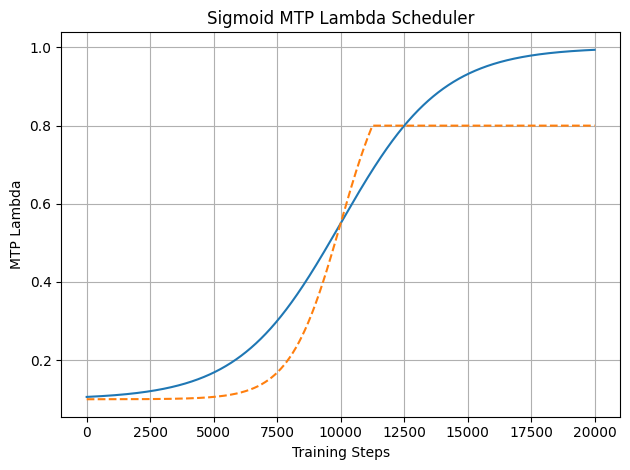

In [55]:
# plot this scheduler
total_steps = 20_000
scheduler = SigmoidMTPLambdaScheduler(
    start_value=0.1, 
    end_value=1.0, 
    total_steps=total_steps, 
    steepness=10
)

mtp_lambdas = []
for step in range(total_steps + 1):
    scheduler.last_step = step
    mtp_lambdas.append(scheduler.get_mtp_lambda())

scheduler = SigmoidMTPLambdaScheduler(
    start_value=0.1, 
    end_value=1.0, 
    total_steps=total_steps, 
    steepness=20
)

scheduler2 = CustomSigmoidMTPLambdaScheduler(
    start_value=0.1, 
    end_value=1.0, 
    total_steps=total_steps, 
    steepness=20
)

mtp_lambdas2 = []
for step in range(20_000 + 1):
    scheduler2.last_step = step
    mtp_lambdas2.append(scheduler2.get_mtp_lambda())

plt.plot(range(total_steps + 1), mtp_lambdas)
plt.plot(range(total_steps + 1), mtp_lambdas2, linestyle='--')
plt.title("Sigmoid MTP Lambda Scheduler")
plt.xlabel("Training Steps")
plt.ylabel("MTP Lambda")
plt.grid()
plt.tight_layout()
plt.show()

In [2]:
from typing import Tuple

def custom_merge_strings_vowels(strings: Tuple[str, str]) -> str: 
    """ Merge two strings by alternately taking characters from each string, omitting any vowels from the input strings, 
        then inserting a vowel between each character in the merged string before reversing it.
        >>> custom_merge_strings_vowels('','')
        ''
        >>> custom_merge_strings_vowels('bcdfgh','jklmnp')
        'unspolmkjhgfecbd'
        >>> custom_merge_strings_vowels('abc','def')
        'eodaubc'
    """
    vowels = 'aeiou'

    strings = [s.lower() for s in strings]

    strings_no_vowels = [''.join([ch for ch in s if ch not in vowels]) for s in strings]

    merged_string = ''
    for chars in zip(*strings_no_vowels):
        merged_string += ''.join(chars)

    reversed_string = merged_string[::-1]

    final_string = ''
    for i, ch in enumerate(reversed_string):
        final_string += ch + vowels[i % len(vowels)]

    return final_string[:-1]

print(custom_merge_strings_vowels(('bcdfgh','jklmnp')))
print(custom_merge_strings_vowels(('abc','def')))

pahenigomufaledikocujab
facedib


In [4]:
from sympy import symbols, expand
import sympy as sp

x = symbols('x')
expanded = expand((x - 4)**2)

# Print the expanded form
print(expanded)

x**2 - 8*x + 16


In [3]:
class SigmoidMTPLambdaScheduler:
    """Sigmoid schedule for mtp_lambda from start_value to end_value over total_steps."""
    
    def __init__(
        self, 
        start_value: float, 
        end_value: float, 
        total_steps: int, 
        steepness: float = 10.0, 
        cap_value: float = None,
        training_start_portion: float = 0.0,
        training_end_portion: float = 1.0
    ):
        # super().__init__(start_value)
        self.start_value = start_value
        self.end_value = end_value
        self.total_steps = total_steps
        self.steepness = steepness
        self.cap_value = cap_value
        self.training_start_portion = training_start_portion
        self.training_end_portion = training_end_portion

    def get_mtp_lambda(self):
        t = min(self.last_step / self.total_steps, 1.0)
        
        # Adjust t based on start and end portions
        if t <= self.training_start_portion:
            # Before the schedule starts
            adjusted_t = 0.0
        elif t >= self.training_end_portion:
             # After the schedule ends
            adjusted_t = 1.0
        else:
             # During the schedule: normalize t to be between 0 and 1 within the window
            denominator = self.training_end_portion - self.training_start_portion
            if denominator > 0:
                adjusted_t = (t - self.training_start_portion) / denominator
            else:
                 # Start and end portion are the same, jump to end
                adjusted_t = 1.0

        # Sigmoid function centered at adjusted_t=0.5
        sigmoid_t = 1 / (1 + math.exp(-self.steepness * (adjusted_t - 0.5)))
        value = self.start_value + sigmoid_t * (self.end_value - self.start_value)
        if self.cap_value is not None:
            value = min(value, self.cap_value)
        return value

Text(0, 0.5, 'MTP Lambda')

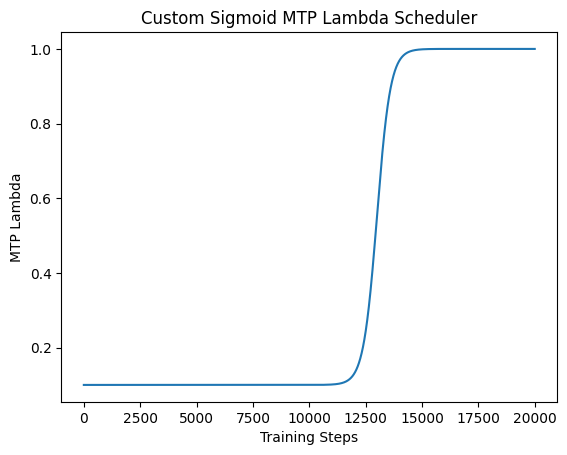

In [7]:
scheduler = SigmoidMTPLambdaScheduler(
    start_value=0.1, 
    end_value=1.0, 
    total_steps=20_000, 
    steepness=20,
    # cap_value=0.8,
    training_start_portion=0.5,
    training_end_portion=0.8
)

import numpy as np
import matplotlib.pyplot as plt
import math

mtp_lambdas = []
for step in range(20_000 + 1):
    scheduler.last_step = step
    mtp_lambdas.append(scheduler.get_mtp_lambda())

plt.plot(range(20_000 + 1), mtp_lambdas)
plt.title("Custom Sigmoid MTP Lambda Scheduler")
plt.xlabel("Training Steps")
plt.ylabel("MTP Lambda")

In [63]:
import torch
input_tensor = torch.randn(1, 10)

In [134]:
linear = torch.nn.Linear(10, 10)
# linear.weight.data.data.normal_(mean=20, std=0.02)
# random input
output = linear(input_tensor)
torch.sigmoid(output+-3).mean()

tensor(0.0588, grad_fn=<MeanBackward0>)

In [108]:
linear.weight.data

tensor([[20.0114, 19.9979, 20.0212, 20.0349, 20.0149, 19.9796, 20.0285, 19.9961,
         19.9518, 20.0047],
        [20.0325, 19.9955, 19.9830, 19.9981, 20.0021, 20.0105, 19.9976, 20.0330,
         19.9882, 20.0004],
        [20.0147, 20.0058, 19.9818, 19.9921, 19.9696, 19.9796, 20.0429, 20.0096,
         20.0219, 19.9828],
        [20.0001, 19.9988, 19.9768, 19.9972, 20.0235, 19.9856, 19.9738, 19.9694,
         19.9964, 19.9979],
        [20.0029, 20.0159, 19.9790, 19.9775, 19.9787, 19.9868, 19.9986, 19.9675,
         19.9633, 19.9984],
        [20.0138, 19.9844, 20.0041, 19.9672, 19.9703, 19.9626, 19.9815, 20.0148,
         20.0051, 20.0066],
        [19.9999, 20.0203, 19.9778, 20.0189, 19.9874, 20.0294, 20.0140, 20.0153,
         19.9880, 20.0363],
        [19.9736, 20.0020, 19.9763, 20.0087, 20.0223, 20.0182, 19.9925, 20.0139,
         19.9857, 20.0136],
        [20.0156, 19.9721, 20.0276, 20.0233, 19.9886, 19.9604, 20.0560, 20.0112,
         19.9861, 20.0379],
        [20.0369, 2

In [98]:
input_tensor

tensor([[-0.6129,  0.7791, -0.0731, -1.0821, -0.7316,  1.2580,  0.5971, -0.6538,
         -0.2165, -1.1971]])

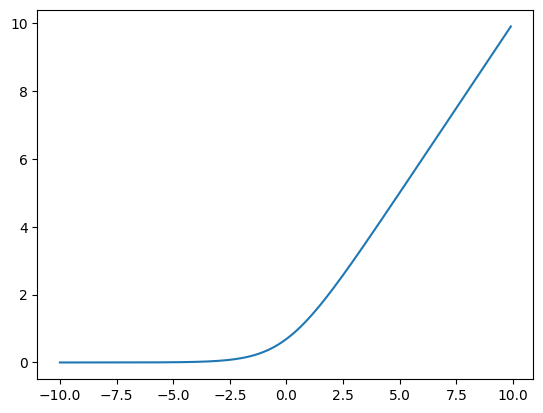

In [1]:
import torch
from torch.nn.functional import softplus, softmax
x = torch.arange(-10, 10, 0.1)
y = softplus(x)


import matplotlib.pyplot as plt
plt.plot(x.numpy(), y.numpy())

In [4]:
softplus(torch.tensor(-3.0))

tensor(0.0486)

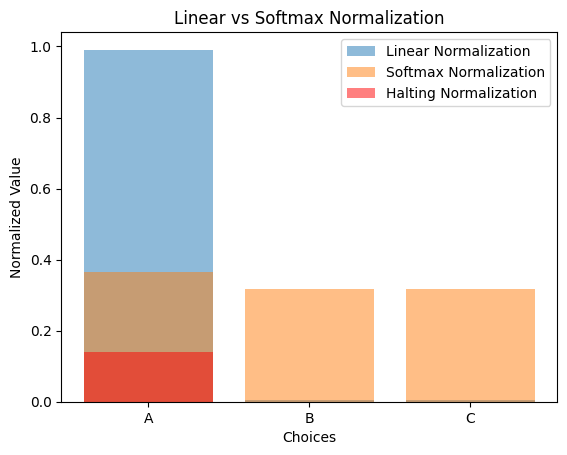

In [13]:
# x = torch.tensor([0.98, 0.015, 0.005])
# x = torch.tensor([0.3, 0.25, 0.1])
x = torch.tensor([0.14, 0.0006, 0.0007])
y_linear = x / x.sum()
y_softmax = softmax(x, dim=0)

y_halting = []
unhalted = 1.0
for xi in x:
    y_halting.append(unhalted * xi.item())
    unhalted *= (1 - xi.item())
x[-1] = unhalted
# plot
plt.bar(range(len(x)), y_linear, alpha=0.5, label='Linear Normalization')
plt.bar(range(len(x)), y_softmax, alpha=0.5, label='Softmax Normalization')
plt.bar(range(len(x)), y_halting, alpha=0.5, label='Halting Normalization', color='red')
plt.xticks(range(len(x)), ['A', 'B', 'C'])
plt.title("Linear vs Softmax Normalization")
plt.xlabel("Choices")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()

In [15]:
y_linear

tensor([0.9908, 0.0042, 0.0050])

In [12]:
y_softmax

tensor([0.3650, 0.3175, 0.3175])

In [14]:
y_halting

[0.14000000059604645, 0.000516000024151057, 0.0006016387781136181]

In [1]:
from torch.nn import functional as F
import torch
x1 = torch.tensor([1,1], dtype=torch.float)
x2 = torch.tensor([1, 1], dtype=torch.float)

1-F.cosine_similarity(x1, x2, dim=0)

tensor(5.9605e-08)

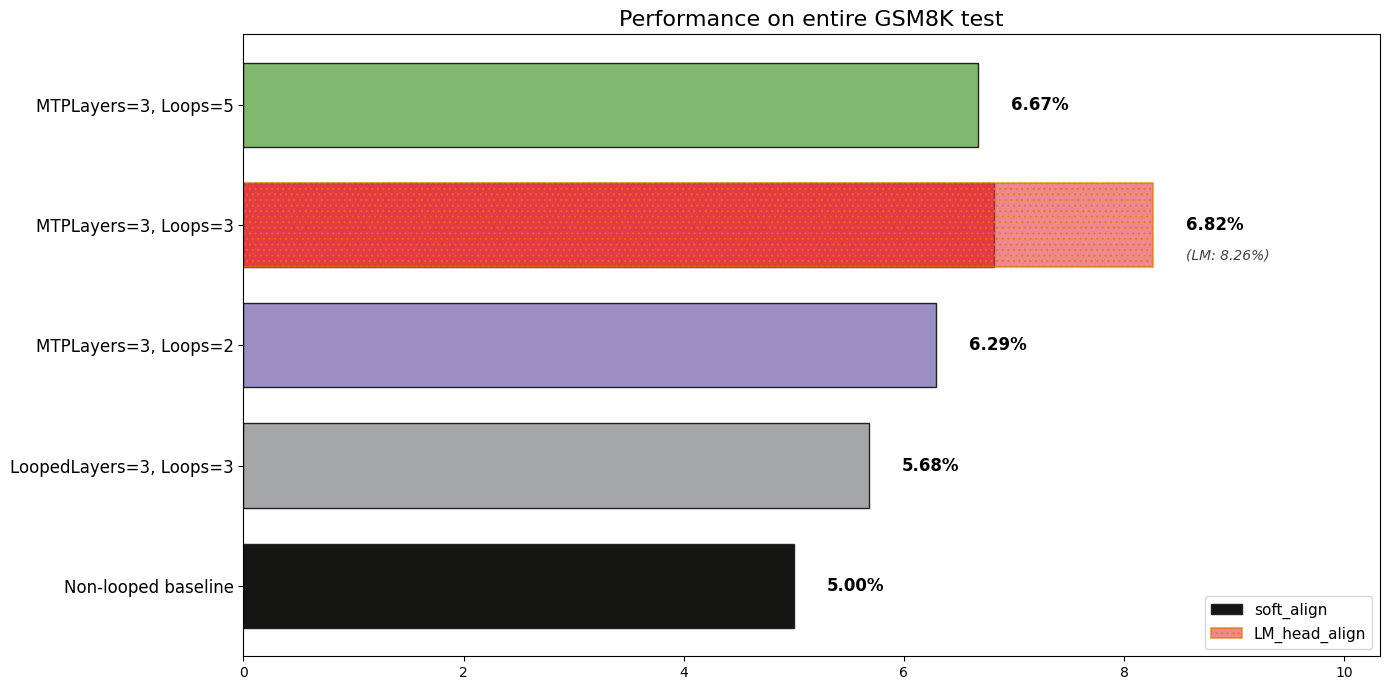

In [2]:
import matplotlib.pyplot as plt

data = {
    "Non-looped baseline": {
        "soft_align": 0.0500,
        "LM_head_align": None
    },
    "LoopedLayers=3, Loops=3": {
        "soft_align": 0.0568,
        "LM_head_align": None
    },
    "MTPLayers=3, Loops=2": {
        "soft_align": 0.0629,
        "LM_head_align": None
    },
    "MTPLayers=3, Loops=3": {
        "soft_align": 0.0682,
        "LM_head_align": 0.0826
    },
    "MTPLayers=3, Loops=5": {
        "soft_align": 0.0667,
        "LM_head_align": None
    },

}

labels = list(data.keys())
soft_values = [d["soft_align"] * 100 for d in data.values()]
lm_values = [d["LM_head_align"] * 100 if d.get("LM_head_align") is not None else None for d in data.values()]
wo_align_values = [d["wo/ align"] * 100 if d.get("wo/ align") is not None else None for d in data.values()]

colors = ["#151514", "#797a7eab", "#9b8ec4", "#e63946", "#80b86d", "#2d48c4"]

fig, ax = plt.subplots(figsize=(14, 7))

# Plot soft_align bars
bars = ax.barh(range(len(labels)), soft_values, color=colors, height=0.7, label='soft_align', edgecolor="#222220")

# Plot LM_head_align hatched bars on top where not None
lm_label_added = False
for i, lm_val in enumerate(lm_values):
    if lm_val is not None:
        ax.barh(i, lm_val, color=colors[i], height=0.7, edgecolor='#e07b00',
                linewidth=1.5, hatch='...', alpha=0.6,
                label='LM_head_align' if not lm_label_added else None)
        lm_label_added = True

# Plot wo/ align hatched bars where not None
wo_label_added = False
for i, wo_val in enumerate(wo_align_values):
    if wo_val is not None:
        ax.barh(i, wo_val, color=colors[i], height=0.7, edgecolor='#e07b00',
                linewidth=1.5, hatch='...', alpha=0.55,
                label='wo/ align' if not wo_label_added else None)
        wo_label_added = True

# Annotate values
for i, (bar, soft_val) in enumerate(zip(bars, soft_values)):
    lm_val = lm_values[i]
    wo_val = wo_align_values[i]
    candidates = [v for v in [soft_val, lm_val, wo_val] if v is not None]
    max_val = max(candidates)
    ax.text(max_val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{soft_val:.2f}%', va='center', fontsize=12, fontweight='bold')
    if lm_val is not None:
        ax.text(max_val + 0.3, bar.get_y() + bar.get_height() / 2 - 0.25,
                f'(LM: {lm_val:.2f}%)', va='center', fontsize=10, fontstyle='italic', color='#444')
    if wo_val is not None:
        ax.text(max_val + 0.3, bar.get_y() + bar.get_height() / 2 - 0.5,
                f'(wo/ align: {wo_val:.2f}%)', va='center', fontsize=10, fontstyle='italic', color='#e07b00')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=12)
ax.set_title("Performance on entire GSM8K test", fontsize=16)
all_vals = [v for v in soft_values + [v for v in lm_values if v is not None] + [v for v in wo_align_values if v is not None]]
ax.set_xlim(0, max(all_vals) * 1.25)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()


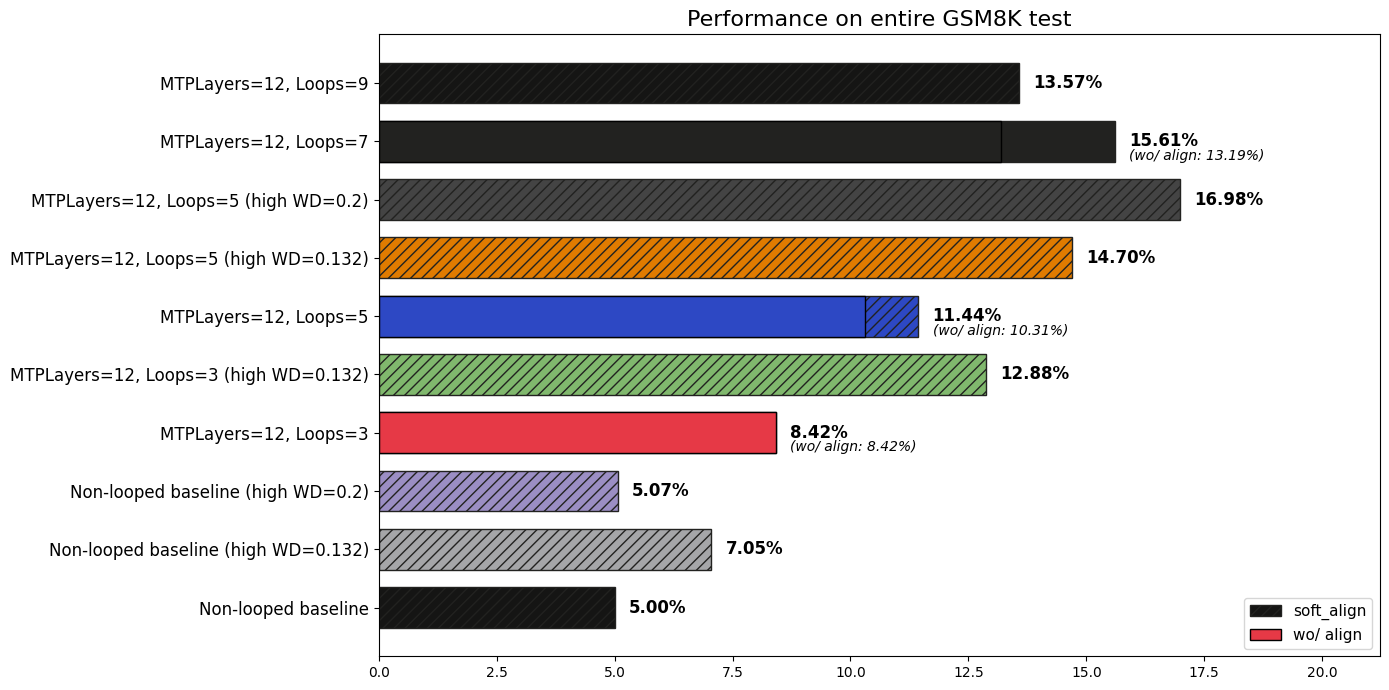

In [ ]:
import matplotlib.pyplot as plt

data = {
    "Non-looped baseline": {
        "soft_align": 0.0500,
        "LM_head_align": None
    },
    "Non-looped baseline (high WD=0.132)": {
        "soft_align": 0.0705,
        "LM_head_align": None
    },
    "Non-looped baseline (high WD=0.2)": {
        "soft_align": 0.0507,
        "LM_head_align": None
    },
    "MTPLayers=12, Loops=3": {
        "soft_align": 0.084155,
        # "LM_head_align": 0.0773,
        "wo/ align": 0.084155
    },
    "MTPLayers=12, Loops=3 (high WD=0.132)": {
        "soft_align": 0.1288,
        # "LM_head_align": 0.0773,
        "wo/ align": None
    },
    "MTPLayers=12, Loops=3 (high WD=0.2)": {
        "soft_align": 0.1213,
        # "LM_head_align": 0.0773,
        "wo/ align": None
    },
    "MTPLayers=12, Loops=5": {
        "soft_align": 0.1144,
        "LM_head_align": None,
        "wo/ align": 0.10311
    },
    "MTPLayers=12, Loops=5 (high WD=0.132)": {
        "soft_align": 0.1470,
        "LM_head_align": None,
        "wo/ align": None
    },
    "MTPLayers=12, Loops=5 (high WD=0.2)": {
        "soft_align": 0.1698,
        "LM_head_align": None,
        "wo/ align": None
    },
    "MTPLayers=12, Loops=7": {
        "soft_align": 0.1561,
        "LM_head_align": None,
        "wo/ align": 0.1319
    },
    "MTPLayers=12, Loops=9": {
        "soft_align": 0.1357,
        "LM_head_align": None
    }
}

labels = list(data.keys())
soft_values = [d["soft_align"] * 100 for d in data.values()]
lm_values = [d["LM_head_align"] * 100 if d.get("LM_head_align") is not None else None for d in data.values()]
wo_align_values = [d["wo/ align"] * 100 if d.get("wo/ align") is not None else None for d in data.values()]

colors = ["#151514", "#797a7eab", "#9b8ec4", "#e63946", "#80b86d", "#2d48c4", "#e07b00", "#444444", "#222220"]

fig, ax = plt.subplots(figsize=(14, 7))

# Plot soft_align bars
bars = ax.barh(range(len(labels)), soft_values, color=colors, height=0.7, label='soft_align', edgecolor="#222220", hatch='///', linewidth=1)

# Plot LM_head_align hatched bars on top where not None
lm_label_added = False
for i, lm_val in enumerate(lm_values):
    if lm_val is not None:
        ax.barh(i, lm_val, color=colors[i], height=0.7, edgecolor='#e07b00',
                linewidth=1.5, hatch='...', alpha=0.6,
                label='LM_head_align' if not lm_label_added else None)
        lm_label_added = True

# Plot wo/ align hatched bars where not None
wo_label_added = False
for i, wo_val in enumerate(wo_align_values):
    if wo_val is not None:
        ax.barh(i, wo_val, color=colors[i], height=0.7, edgecolor='black',
                linewidth=1,
                label='wo/ align' if not wo_label_added else None)
        wo_label_added = True

# Annotate values
for i, (bar, soft_val) in enumerate(zip(bars, soft_values)):
    lm_val = lm_values[i]
    wo_val = wo_align_values[i]
    candidates = [v for v in [soft_val, lm_val, wo_val] if v is not None]
    max_val = max(candidates)
    ax.text(max_val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{soft_val:.2f}%', va='center', fontsize=12, fontweight='bold')
    if lm_val is not None:
        ax.text(max_val + 0.3, bar.get_y() + bar.get_height() / 2 - 0.25,
                f'(LM: {lm_val:.2f}%)', va='center', fontsize=10, fontstyle='italic', color='#444')
    if wo_val is not None:
        ax.text(max_val + 0.3, bar.get_y() + bar.get_height() / 2 - 0.25,
                f'(wo/ align: {wo_val:.2f}%)', va='center', fontsize=10, fontstyle='italic', color='black')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=12)
ax.set_title("Performance on entire GSM8K test", fontsize=16)
all_vals = [v for v in soft_values + [v for v in lm_values if v is not None] + [v for v in wo_align_values if v is not None]]
ax.set_xlim(0, max(all_vals) * 1.25)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()


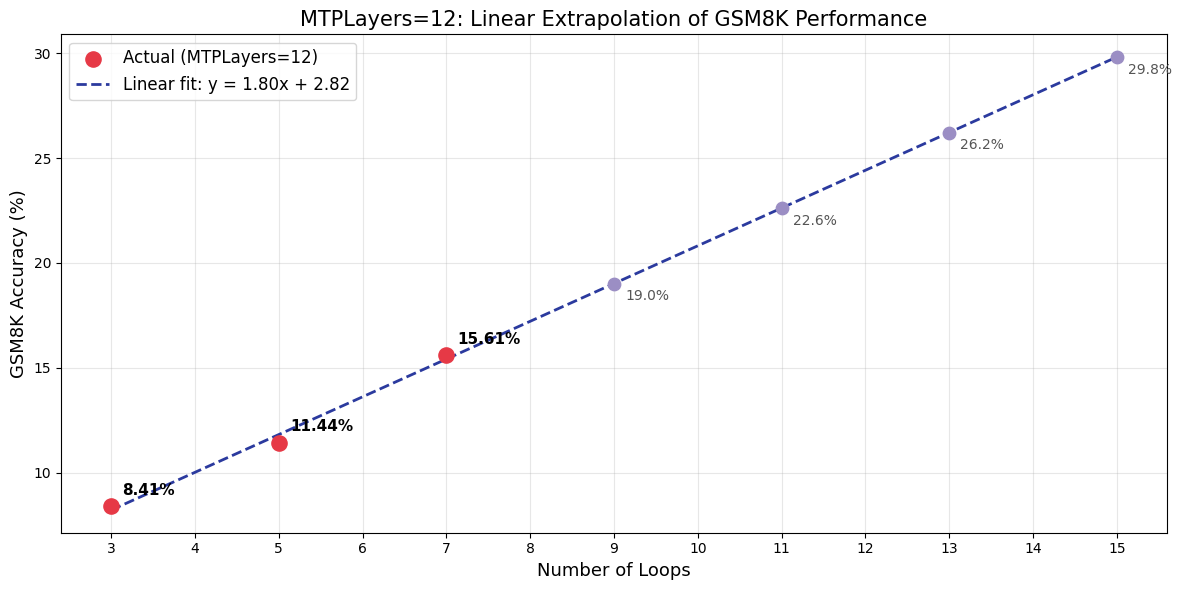

Linear fit: accuracy = 1.800 * loops + 2.820
  Loops=9: predicted accuracy = 19.02%
  Loops=11: predicted accuracy = 22.62%
  Loops=13: predicted accuracy = 26.22%
  Loops=15: predicted accuracy = 29.82%
  Loops=20: predicted accuracy = 38.82%


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# MTPLayers=12 data points: Loops -> accuracy (%)
loops_data = np.array([3, 5, 7])
acc_data = np.array([8.41, 11.44, 15.61])

# Fit linear regression on the 3 MTPLayers=12 points
coeffs = np.polyfit(loops_data, acc_data, 1)  # slope, intercept
poly = np.poly1d(coeffs)

# Extrapolate to higher loop counts
loops_extrap = np.arange(3, 16)
acc_extrap = poly(loops_extrap)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Actual data points
ax.scatter(loops_data, acc_data, color='#e63946', s=120, zorder=5, label='Actual (MTPLayers=12)')
for l, a in zip(loops_data, acc_data):
    ax.annotate(f'{a:.2f}%', (l, a), textcoords="offset points", xytext=(8, 8), fontsize=11, fontweight='bold')

# Fitted/extrapolated line
ax.plot(loops_extrap, acc_extrap, '--', color='#2b3a9e', linewidth=2, label=f'Linear fit: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')

# Mark a few extrapolated points
for l in [9, 11, 13, 15]:
    val = poly(l)
    ax.scatter(l, val, color='#9b8ec4', s=80, zorder=4)
    ax.annotate(f'{val:.1f}%', (l, val), textcoords="offset points", xytext=(8, -12), fontsize=10, color='#555')

ax.set_xlabel("Number of Loops", fontsize=13)
ax.set_ylabel("GSM8K Accuracy (%)", fontsize=13)
ax.set_title("MTPLayers=12: Linear Extrapolation of GSM8K Performance", fontsize=15)
ax.set_xticks(loops_extrap)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Linear fit: accuracy = {coeffs[0]:.3f} * loops + {coeffs[1]:.3f}")
for l in [9, 11, 13, 15, 20]:
    print(f"  Loops={l}: predicted accuracy = {poly(l):.2f}%")

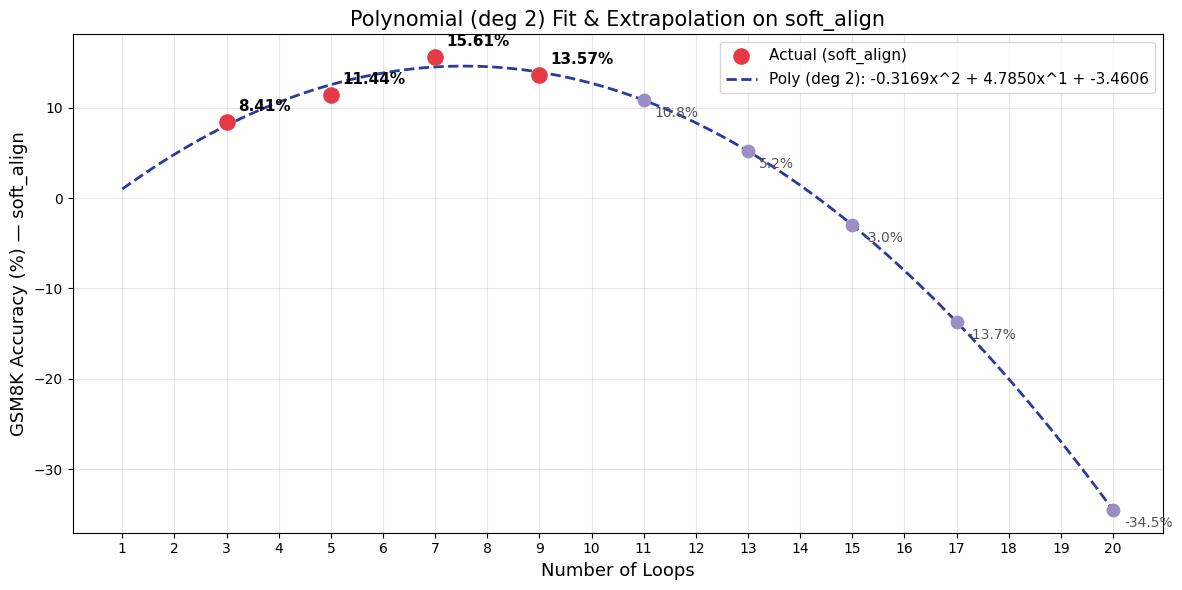


Degree-2 polynomial coefficients: [-0.316875  4.785    -3.460625]
  Loops=9: predicted soft_align accuracy = 13.94%
  Loops=11: predicted soft_align accuracy = 10.83%
  Loops=13: predicted soft_align accuracy = 5.19%
  Loops=15: predicted soft_align accuracy = -2.98%
  Loops=17: predicted soft_align accuracy = -13.69%
  Loops=20: predicted soft_align accuracy = -34.51%


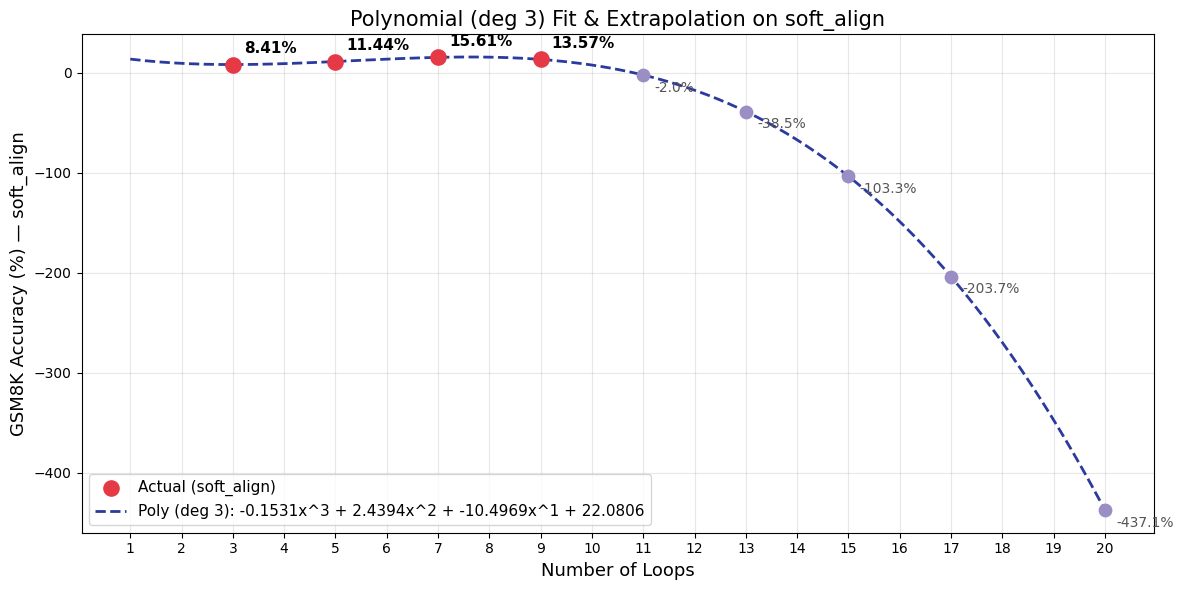


Degree-3 polynomial coefficients: [ -0.153125   2.439375 -10.496875  22.080625]
  Loops=9: predicted soft_align accuracy = 13.57%
  Loops=11: predicted soft_align accuracy = -2.03%
  Loops=13: predicted soft_align accuracy = -38.54%
  Loops=15: predicted soft_align accuracy = -103.31%
  Loops=17: predicted soft_align accuracy = -203.69%
  Loops=20: predicted soft_align accuracy = -437.11%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# All soft_align data points: (loops, accuracy %)
# Non-looped baseline = 1 loop (single pass)
loops_all = np.array([3, 5, 7, 9])
acc_all = np.array([8.41, 11.44, 15.61, 13.57])

# Fit polynomials of degree 2 and 3
for deg in [2, 3]:
    coeffs = np.polyfit(loops_all, acc_all, deg)
    poly = np.poly1d(coeffs)

    # Extrapolate
    loops_extrap = np.linspace(1, 20, 200)
    acc_extrap = poly(loops_extrap)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Actual data points
    ax.scatter(loops_all, acc_all, color='#e63946', s=120, zorder=5, label='Actual (soft_align)')
    for l, a in zip(loops_all, acc_all):
        ax.annotate(f'{a:.2f}%', (l, a), textcoords="offset points", xytext=(8, 8),
                    fontsize=11, fontweight='bold')

    # Fitted/extrapolated curve
    eq_str = ' + '.join([f'{c:.4f}x^{deg-i}' if deg-i > 0 else f'{c:.4f}'
                         for i, c in enumerate(coeffs)])
    ax.plot(loops_extrap, acc_extrap, '--', color='#2b3a9e', linewidth=2,
            label=f'Poly (deg {deg}): {eq_str}')

    # Mark extrapolated points
    for l in [11, 13, 15, 17, 20]:
        val = poly(l)
        ax.scatter(l, val, color='#9b8ec4', s=80, zorder=4)
        ax.annotate(f'{val:.1f}%', (l, val), textcoords="offset points",
                    xytext=(8, -12), fontsize=10, color='#555')

    ax.set_xlabel("Number of Loops", fontsize=13)
    ax.set_ylabel("GSM8K Accuracy (%) — soft_align", fontsize=13)
    ax.set_title(f"Polynomial (deg {deg}) Fit & Extrapolation on soft_align", fontsize=15)
    ax.set_xticks(range(1, 21))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nDegree-{deg} polynomial coefficients: {coeffs}")
    for l in [9, 11, 13, 15, 17, 20]:
        print(f"  Loops={l}: predicted soft_align accuracy = {poly(l):.2f}%")